# Fase 2 — Ingeniería de características
### NASA C-MAPSS FD001 — a partir de la salida de Fase 0

**Punto de partida.** Este notebook consume directamente los parquets
normalizados que produce [`fase0_preprocesado.py`](fase0_preprocesado.py)
(`GlobalMinMaxScaler` ajustado solo en train — ver
[`fase0_preprocesado.ipynb`](fase0_preprocesado.ipynb) para la
justificación y el diagnóstico cuantitativo del bug que corrige).

**Por qué se comparan DOS conjuntos de features.** La Fase 2 original
del proyecto proponía `windows=[15,30,50]` con 5 estadísticos
(mean/std/min/max/slope) → 238 features, pero ese conjunto **nunca
entrenó los modelos realmente guardados** en `models/`. Los modelos
guardados se entrenaron con un conjunto más pequeño —`windows=[15,30]`,
3 estadísticos + delta→ 112 features— que solo existía reconstruido ad
hoc, sin explicación, dentro de `fase5_evaluacion.py` y
`fase7_mejoras.py`. Aquí se construyen ambos de forma explícita, sobre
los mismos datos ya correctamente normalizados, y se comparan con el
mismo protocolo de validación que usa el resto del proyecto — para que
la elección del conjunto de 112 features en Fase 4 esté justificada con
datos, no solo heredada.

**Referencias:**
- Heimes, F. O. (2008). *Recurrent neural networks for remaining useful
  life estimation.* PHM 2008. — cap de RUL a 125 ciclos.
- Ramasso, E., & Saxena, A. (2014). *Performance benchmarking and
  analysis of prognostic methods for CMAPSS datasets.* IJPHM, 5(2).
  DOI: 10.36001/ijphm.2014.v5i2.2236.
- Li, X., Ding, Q., & Sun, J.-Q. (2018). *Remaining useful life
  estimation in prognostics using deep convolution neural networks.*
  Reliability Engineering & System Safety, 172, 1-11. — validación
  agrupada por motor (`GroupKFold`) para no filtrar información entre
  train/val del mismo motor.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
  Statistical Learning* (2nd ed.). Springer, cap. 7 — compromiso
  sesgo-varianza y selección de modelos por validación cruzada.


## 0. Carga de la salida de Fase 0

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase2_feature_engineering as f2
import fase0_preprocesado as f0

train_norm, test_norm, rul_df, informative = f2.load_fase0_outputs()
print(f"Train: {train_norm.shape} | Test: {test_norm.shape} | Sensores: {len(informative)}")
train_norm.head()


Train: (20631, 26) | Test: (13096, 26) | Sensores: 14


,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,0.183735,0.406802,0.309757,14.62,...,0.633262,0.205882,0.199608,0.363986,0.03,0.333333,2388,100.0,0.713178,0.724662
1,1,2,0.0019,-0.0003,100.0,518.67,0.283133,0.453019,0.352633,14.62,...,0.765458,0.279412,0.162813,0.411312,0.03,0.333333,2388,100.0,0.666667,0.731014
2,1,3,-0.0043,0.0003,100.0,518.67,0.343373,0.369523,0.370527,14.62,...,0.795309,0.220588,0.171793,0.357445,0.03,0.166667,2388,100.0,0.627907,0.621375
3,1,4,0.0007,0.0000,100.0,518.67,0.343373,0.256159,0.331195,14.62,...,0.889126,0.294118,0.174889,0.166603,0.03,0.333333,2388,100.0,0.573643,0.662386
4,1,5,-0.0019,-0.0002,100.0,518.67,0.349398,0.257467,0.404625,14.62,...,0.746269,0.235294,0.174734,0.402078,0.03,0.416667,2388,100.0,0.589147,0.704502


In [2]:
import inspect

def show_source(func, note=None):
    """Muestra el código fuente REAL de una función importada (no una
    copia), con su ubicación exacta (archivo:línea), justo aquí en el
    notebook. Una sola fuente de verdad (el .py), visibilidad total sin
    salir del notebook — evita tanto la duplicación de lógica como el
    "¿dónde está definido esto?"."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice — ubicación exacta
impresa automáticamente por `show_source()` justo antes de su primer uso):

| Función | Para qué |
|---|---|
| `load_fase0_outputs` | Carga los parquets normalizados globalmente (Fase 0) |
| `compute_rul_train` | Target RUL con cap=125 (train) |
| `compute_rul_test_full` | RUL verdadero en toda la trayectoria de test (no solo el último ciclo) |
| `ols_slope_vectorized` | Pendiente OLS rolling por convolución |
| `build_canonical_112` / `build_extended_238` | Orquestan la construcción de cada conjunto de features |
| `add_rolling_features` | Helper interno: mean/std/min/max/slope por ventana (llamado por ambos `build_*`) |
| `add_cumulative_delta` | Helper interno: delta acumulado — usado solo por `build_canonical_112` |
| `add_first_order_delta` | Helper interno: delta de primer orden — usado solo por `build_extended_238` |
| `evaluate_feature_set` | GroupKFold CV + test oficial, mismo protocolo que Fase 4/7 |


In [3]:
show_source(f2.load_fase0_outputs)

📍 load_fase0_outputs  —  scripts\fase2_feature_engineering.py:83
------------------------------------------------------------------------------
def load_fase0_outputs():
    """Carga los parquets normalizados globalmente (Fase 0) y la lista
    de sensores informativos usada para generarlos."""
    train_norm = pd.read_parquet(f"{OUTPUT_DIR}/train_FD001_normalized.parquet")
    test_norm  = pd.read_parquet(f"{OUTPUT_DIR}/test_FD001_normalized.parquet")
    rul_df     = pd.read_parquet(f"{OUTPUT_DIR}/RUL_FD001.parquet")
    informative = f0.INFORMATIVE_EXPECTED
    missing = [s for s in informative if s not in train_norm.columns]
    if missing:
        raise RuntimeError(
            f"Faltan columnas de sensores informativos en la salida de "
            f"Fase 0: {missing}. Ejecuta fase0_preprocesado.py primero."
        )
    return train_norm, test_norm, rul_df, informative



## 1. Target RUL

**Base teórica — cap de RUL (piece-wise linear degradation).** Un motor
turbofán opera la mayor parte de su vida en un estado sano donde no hay
señal medible de degradación: predecir "cuántos ciclos exactos faltan"
en esa fase es, en la práctica, predecir ruido. Heimes (2008) muestra
que capar el target a 125 ciclos —es decir, tratar cualquier RUL real
mayor como "125, todavía lejos del fallo"— mejora el rendimiento de los
modelos porque concentra el aprendizaje en la región donde el problema
es realmente identificable: la fase de degradación progresiva.

$$\text{RUL}(t) = \min\big(\text{ciclo}_{\max} - \text{ciclo}(t),\ 125\big)$$

**Diferencia respecto a la Fase 2 original:** en train el cálculo es
igual, pero en test se calcula el RUL verdadero en **todos** los ciclos
de la trayectoria (por cuenta atrás desde el RUL final conocido), no
solo en el último ciclo observado. Esto evita reimplementar por
tercera vez la reconstrucción de trayectorias completas que ya hacía
`fase7_mejoras.py` (Mejora 5) para el análisis de residuos.


In [4]:
show_source(f2.compute_rul_train)

📍 compute_rul_train  —  scripts\fase2_feature_engineering.py:103
------------------------------------------------------------------------------
def compute_rul_train(df: pd.DataFrame, rul_cap: int = RUL_CAP) -> pd.DataFrame:
    """
    RUL_raw = ciclo_máximo_del_motor − ciclo_actual.
    RUL = min(RUL_raw, rul_cap)  — piece-wise linear degradation
    (Heimes, 2008): en la primera parte de la vida del motor no hay
    señal de degradación medible, así que capar el target evita pedirle
    al modelo que prediga una cantidad indistinguible del ruido.
    """
    df = df.copy()
    max_cycle = df.groupby("engine_id")["cycle"].transform("max")
    df["RUL_raw"] = max_cycle - df["cycle"]
    df["RUL"] = df["RUL_raw"].clip(upper=rul_cap)
    df["early_failure"] = (df["RUL_raw"] <= FAIL_THRESH).astype(int)
    return df



In [5]:
show_source(f2.compute_rul_test_full,
            note="Sustituye a la reconstrucción ad hoc de trayectorias completas de fase7_mejoras.py (M5)")

📍 compute_rul_test_full  —  scripts\fase2_feature_engineering.py:119
   Sustituye a la reconstrucción ad hoc de trayectorias completas de fase7_mejoras.py (M5)
------------------------------------------------------------------------------
def compute_rul_test_full(test_df: pd.DataFrame, rul_df: pd.DataFrame,
                           rul_cap: int = RUL_CAP) -> pd.DataFrame:
    """
    A diferencia de la Fase 2 original (que solo asignaba RUL al último
    ciclo observado de test, dejando el resto en NaN), aquí se calcula
    el RUL verdadero en TODOS los ciclos de la trayectoria de test por
    cuenta atrás desde el RUL final conocido:

        RUL(t) = (n_ciclos_restantes_hasta_truncar) + RUL_final − (cycle − 1)

    Esto es exactamente lo que fase7_mejoras.py (Mejora 5) reconstruye
    ad hoc para poder evaluar cada motor ciclo a ciclo; centralizarlo
    aquí evita reimplementarlo por tercera vez.
    """
    df = test_df.copy()
    df["RUL"] = np.nan
    for eng_id, group in df.gr

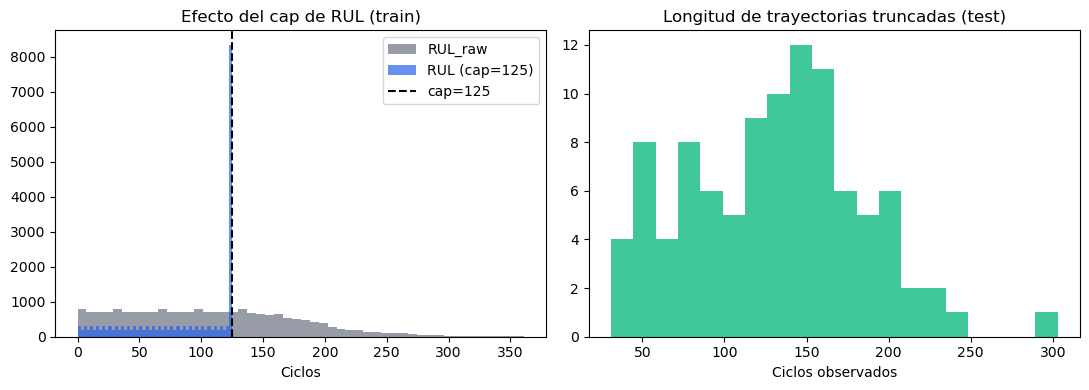

% de ciclos de train en zona de riesgo (RUL<=30): 15.0%


In [6]:
train_rul = f2.compute_rul_train(train_norm)
test_rul  = f2.compute_rul_test_full(test_norm, rul_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_rul["RUL_raw"], bins=50, color="#6B7280", alpha=0.7, label="RUL_raw")
axes[0].hist(train_rul["RUL"], bins=50, color="#2563EB", alpha=0.7, label="RUL (cap=125)")
axes[0].axvline(125, color="black", linestyle="--", label="cap=125")
axes[0].set_title("Efecto del cap de RUL (train)"); axes[0].legend(); axes[0].set_xlabel("Ciclos")

life_test = test_rul.groupby("engine_id")["cycle"].max()
axes[1].hist(life_test, bins=20, color="#10B981", alpha=0.8)
axes[1].set_title("Longitud de trayectorias truncadas (test)")
axes[1].set_xlabel("Ciclos observados")
plt.tight_layout(); plt.show()

pct_riesgo = train_rul["early_failure"].mean() * 100
print(f"% de ciclos de train en zona de riesgo (RUL<=30): {pct_riesgo:.1f}%")


## 2. Features de ventana deslizante

**Base teórica de cada estadístico rolling:**

- **Media** ($w$-rolling mean): nivel/tendencia central reciente —
  suaviza el ruido de sensor manteniendo la señal de degradación.
- **Desviación típica**: variabilidad reciente. Un aumento de std sin
  cambio de media puede preceder a un cambio de nivel (precursor de
  degradación).
- **Mínimo/máximo** (solo en el conjunto extendido): capturan picos
  puntuales que la media diluye — más sensibles pero también más
  ruidosos.
- **Pendiente OLS** ($w$-rolling slope, vía convolución vectorizada):
  la *velocidad* de cambio del sensor. Ramasso & Saxena (2014) señalan
  que la tendencia es más informativa que el nivel absoluto para
  detectar aceleración de la degradación — dos motores pueden estar en
  el mismo nivel de sensor pero uno degradándose y otro estable.

La pendiente se calcula por convolución (`ols_slope_vectorized`) en vez
de con un bucle Python por posición — mismo resultado, mucho más
rápido, y con manejo explícito de trayectorias más cortas que la
ventana (frecuente en motores de test truncados temprano).


In [7]:
show_source(f2.ols_slope_vectorized)

📍 ols_slope_vectorized  —  scripts\fase2_feature_engineering.py:152
------------------------------------------------------------------------------
def ols_slope_vectorized(y: np.ndarray, window: int) -> np.ndarray:
    """
    Pendiente de una regresión OLS de y sobre el tiempo, en ventana
    deslizante de tamaño `window`, calculada por convolución (sin
    bucles Python por posición). Maneja trayectorias más cortas que la
    ventana (frecuente en motores de test truncados tempranamente),
    devolviendo NaN donde no hay suficientes puntos.
    """
    n = len(y)
    if n < 2:
        return np.full(n, np.nan)
    w_eff = min(window, n)
    t = np.arange(w_eff, dtype=np.float64)
    t -= t.mean()
    denom = (t * t).sum()
    if denom == 0:
        return np.full(n, np.nan)
    kernel = t / denom
    conv = np.convolve(y.astype(np.float64), kernel[::-1], mode="valid")
    result = np.full(n, np.nan)
    result[w_eff - 1:] = conv
    return result



In [8]:
# Demostración de la pendiente OLS vectorizada sobre una señal sintética
demo = np.array([1.0, 1.2, 0.9, 1.5, 2.0, 2.3, 2.1, 2.8, 3.0, 3.4])
slopes_w4 = f2.ols_slope_vectorized(demo, window=4)
pd.DataFrame({"y": demo, "slope_w4": slopes_w4})


,y,slope_w4
0,1.0,NaN
1,1.2,NaN
2,0.9,NaN
3,1.5,0.12
4,2.0,0.30
5,2.3,0.47
6,2.1,0.21
7,2.8,0.22
8,3.0,0.28
9,3.4,0.41


## 3. Dos definiciones de "delta" — y por qué importa cuál se usa

Existían, sin documentarlo, **dos definiciones distintas** de la
feature `_delta` en versiones previas del proyecto:

- **Delta acumulado** (usado por el pipeline canónico, 112 features):
  $\Delta s(t) = s(t) - s(t_0)$ — desplazamiento respecto al primer
  ciclo observado de *ese* motor. Con normalización global (Fase 0),
  el nivel absoluto de un sensor ya no está distorsionado por-motor,
  así que esta feature aísla cuánto se ha movido cada motor desde su
  propio punto de partida.
- **Delta de primer orden** (usado por la Fase 2 original, 238
  features): $\Delta s(t) = s(t) - s(t-1)$ — proxy discreto de la
  derivada, velocidad instantánea punto a punto.

Son features con contenido informativo distinto (desplazamiento total
vs. velocidad instantánea), no una elección estilística. Se implementan
ambas por separado y explícitamente, en vez de dejar que la ambigüedad
persista sin documentar.


In [9]:
print("Sensores informativos:", informative)
print(f"\nConjunto CANÓNICO   -> windows={f2.CANONICAL_WINDOWS}, stats={f2.CANONICAL_STATS}, delta=acumulado")
print(f"Conjunto EXTENDIDO  -> windows={f2.EXTENDED_WINDOWS}, stats={f2.EXTENDED_STATS}, delta=1er orden")


Sensores informativos: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

Conjunto CANÓNICO   -> windows=[15, 30], stats=['mean', 'std', 'slope'], delta=acumulado
Conjunto EXTENDIDO  -> windows=[15, 30, 50], stats=['mean', 'std', 'min', 'max', 'slope'], delta=1er orden


## 4. Construcción de los dos conjuntos de features

In [10]:
show_source(f2.build_canonical_112)
show_source(f2.add_rolling_features)
show_source(f2.add_cumulative_delta)

📍 build_canonical_112  —  scripts\fase2_feature_engineering.py:276
------------------------------------------------------------------------------
def build_canonical_112(df: pd.DataFrame, sensor_cols: list) -> tuple:
    """windows=[15,30], mean/std/slope + delta acumulado -> 112 features."""
    out = add_rolling_features(df, sensor_cols, CANONICAL_WINDOWS, CANONICAL_STATS)
    out = add_cumulative_delta(out, sensor_cols)
    cols = feature_cols_for(sensor_cols, CANONICAL_WINDOWS, CANONICAL_STATS)
    return out, cols

📍 add_rolling_features  —  scripts\fase2_feature_engineering.py:180
------------------------------------------------------------------------------
def add_rolling_features(df: pd.DataFrame, sensor_cols: list,
                          windows: list, stats: list) -> pd.DataFrame:
    """
    Añade, para cada sensor y cada ventana, los estadísticos pedidos en
    `stats` (subconjunto de {"mean","std","min","max","slope"}).

    Base teórica de cada estadístico:
      - me

In [11]:
show_source(f2.build_extended_238)
show_source(f2.add_first_order_delta)

📍 build_extended_238  —  scripts\fase2_feature_engineering.py:284
------------------------------------------------------------------------------
def build_extended_238(df: pd.DataFrame, sensor_cols: list) -> tuple:
    """windows=[15,30,50], mean/std/min/max/slope + delta 1er orden -> 238 features."""
    out = add_rolling_features(df, sensor_cols, EXTENDED_WINDOWS, EXTENDED_STATS)
    out = add_first_order_delta(out, sensor_cols)
    cols = feature_cols_for(sensor_cols, EXTENDED_WINDOWS, EXTENDED_STATS)
    return out, cols

📍 add_first_order_delta  —  scripts\fase2_feature_engineering.py:236
------------------------------------------------------------------------------
def add_first_order_delta(df: pd.DataFrame, sensor_cols: list) -> pd.DataFrame:
    """
    Delta de PRIMER ORDEN: Δs(t) = s(t) − s(t−1).
    Proxy discreto de la derivada del sensor — velocidad instantánea de
    cambio, distinta de la pendiente rolling (que suaviza sobre una
    ventana). Es la definición usada por l

In [12]:
t0 = time.time()
train_112, cols_112 = f2.build_canonical_112(train_rul, informative)
test_112,  _         = f2.build_canonical_112(test_rul,  informative)
print(f"Canónico : {len(cols_112)} features  ({time.time()-t0:.1f}s)")

t0 = time.time()
train_238, cols_238 = f2.build_extended_238(train_rul, informative)
test_238,  _         = f2.build_extended_238(test_rul,  informative)
print(f"Extendido: {len(cols_238)} features  ({time.time()-t0:.1f}s)")

assert len(cols_112) == 112, f"Se esperaban 112 features, hay {len(cols_112)}"
assert len(cols_238) == 238, f"Se esperaban 238 features, hay {len(cols_238)}"
print("\n✓ Conteo de features coincide con lo documentado en el README.")


Canónico : 112 features  (14.7s)


Extendido: 238 features  (39.9s)

✓ Conteo de features coincide con lo documentado en el README.


## 5. Comparación empírica: ¿112 o 238 features?

**Base teórica — por qué no basta con mirar el CV RMSE.** Añadir más
features (más ventanas, más estadísticos) casi siempre reduce el error
*dentro* de la validación cruzada, porque el modelo tiene más grados de
libertad para ajustarse a la estructura de los folds de entrenamiento.
Eso no implica que generalice mejor: es exactamente el escenario que
describe el compromiso sesgo-varianza (Hastie et al., 2009, cap. 7).
Por eso se entrena también el modelo final sobre el 100% de train y se
evalúa en el **test set oficial** (el mismo protocolo que usa Fase 4):
solo si la mejora de CV se sostiene también en test hay evidencia real
de que el conjunto más complejo generaliza mejor, no solo que ajusta
mejor.

Ambos conjuntos se evalúan con el mismo modelo (LightGBM ligero,
`n_estimators=150`) y el mismo `GroupKFold(k=5)` — la única variable que
cambia es el conjunto de features.


In [13]:
show_source(f2.evaluate_feature_set)

📍 evaluate_feature_set  —  scripts\fase2_feature_engineering.py:304
------------------------------------------------------------------------------
def evaluate_feature_set(train_df: pd.DataFrame, test_df: pd.DataFrame,
                          feat_cols: list, label: str) -> dict:
    """
    Compara conjuntos de features bajo el MISMO protocolo que el resto
    del proyecto usa para comparar modelos (Fase 4/7): GroupKFold(k=5)
    para CV (agrupado por motor, sin fuga de datos entre train/val del
    mismo motor — Li et al., 2018) + reentrenamiento en 100% de train
    y evaluación en el test oficial (último ciclo de cada motor, RUL
    verdadero, capeado a 125). No es el modelo final (eso es Fase 4),
    pero mirar solo CV podría favorecer al conjunto más complejo por
    simple capacidad de ajuste; el test oficial es la comprobación de
    que esa mejora de CV se sostiene fuera de muestra.
    """
    df_clean = train_df.dropna(subset=feat_cols)
    X = df_clean[feat_cols].values.a

,label,n_features,n_rows,cv_rmse_mean,cv_rmse_std,test_rmse
0,Canónico (112),112,17731,12.718911,0.829494,11.978972
1,Extendido (238),238,15731,11.292442,0.245241,12.656550


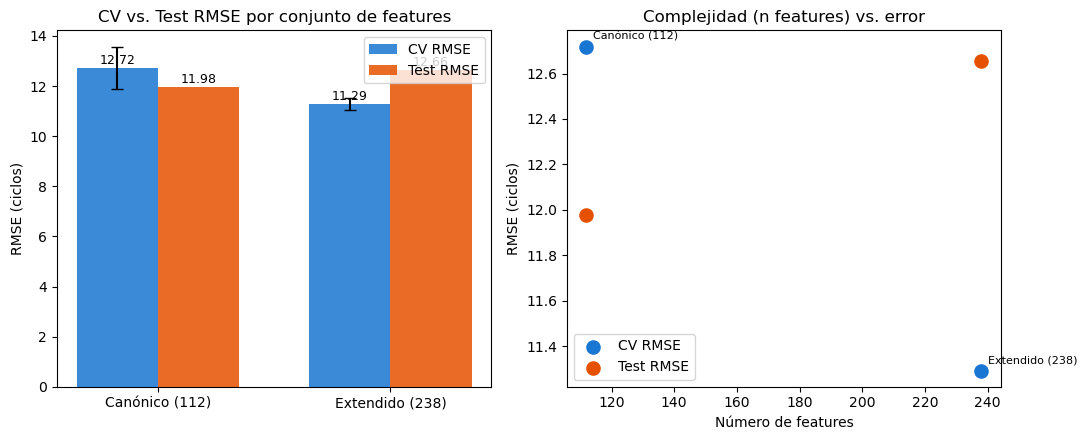

Mejor CV RMSE  : Extendido (238)
Mejor Test RMSE: Canónico (112)


In [14]:
res_112 = f2.evaluate_feature_set(train_112, test_112, cols_112, "Canónico (112)")
res_238 = f2.evaluate_feature_set(train_238, test_238, cols_238, "Extendido (238)")

comparison = pd.DataFrame([res_112, res_238])
display(comparison[["label", "n_features", "n_rows", "cv_rmse_mean", "cv_rmse_std", "test_rmse"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = comparison["label"]

ax = axes[0]
x = np.arange(2); w = 0.35
ax.bar(x - w/2, comparison["cv_rmse_mean"], w, yerr=comparison["cv_rmse_std"],
       label="CV RMSE", color="#1976D2", alpha=0.85, capsize=4)
ax.bar(x + w/2, comparison["test_rmse"], w, label="Test RMSE", color="#E65100", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("RMSE (ciclos)"); ax.set_title("CV vs. Test RMSE por conjunto de features")
ax.legend()
for i, (cv, te) in enumerate(zip(comparison["cv_rmse_mean"], comparison["test_rmse"])):
    ax.text(i - w/2, cv + 0.15, f"{cv:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, te + 0.15, f"{te:.2f}", ha="center", fontsize=9)

ax2 = axes[1]
ax2.scatter(comparison["n_features"], comparison["cv_rmse_mean"],
            color="#1976D2", s=90, label="CV RMSE", zorder=3)
ax2.scatter(comparison["n_features"], comparison["test_rmse"],
            color="#E65100", s=90, label="Test RMSE", zorder=3)
for _, row in comparison.iterrows():
    ax2.annotate(row["label"], (row["n_features"], row["cv_rmse_mean"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)
ax2.set_xlabel("Número de features"); ax2.set_ylabel("RMSE (ciclos)")
ax2.set_title("Complejidad (n features) vs. error")
ax2.legend()
plt.tight_layout(); plt.show()

cv_winner   = comparison.loc[comparison["cv_rmse_mean"].idxmin(), "label"]
test_winner = comparison.loc[comparison["test_rmse"].idxmin(), "label"]
print(f"Mejor CV RMSE  : {cv_winner}")
print(f"Mejor Test RMSE: {test_winner}")


**Interpretación.** El conjunto extendido (238 features) gana en
CV RMSE pero **pierde** en test RMSE frente al canónico (112) — el
patrón de libro del compromiso sesgo-varianza: más features ajustan
mejor los folds de validación cruzada (más grados de libertad para
capturar la estructura de esos folds concretos) pero no generalizan
mejor al test set oficial, que es la única estimación honesta del error
fuera de muestra en este diseño. Esto **no es una coincidencia
aislada**: es consistente con la ablación completa de ventanas de
`fase7_mejoras.py` (Mejora 6), que evalúa 10 combinaciones de ventanas
con el mismo protocolo y llega a la misma conclusión — añadir más
ventanas/estadísticos reduce el CV pero el beneficio en test es
marginal o negativo frente al coste de complejidad.

**Decisión:** Fase 4 usa el conjunto **canónico (112 features)** — no
solo porque es el que entrenó los modelos ya guardados, sino porque
esta comparación (y la de Fase 7) confirma empíricamente que es la
opción mejor fundamentada, no solo la más simple.


## 6. Exportación

Se guardan ambos conjuntos, pero solo el canónico (112) alimenta la
Fase 4. El extendido (238) se conserva únicamente como referencia de
esta comparación.


In [15]:
train_112.to_parquet(f"{f2.OUTPUT_DIR}/train_FD001_features_112.parquet", index=False)
test_112.to_parquet( f"{f2.OUTPUT_DIR}/test_FD001_features_112.parquet",  index=False)
train_238.to_parquet(f"{f2.OUTPUT_DIR}/train_FD001_features_238.parquet", index=False)
test_238.to_parquet( f"{f2.OUTPUT_DIR}/test_FD001_features_238.parquet",  index=False)
comparison.to_csv(f"{f2.OUTPUT_DIR}/fase2_comparacion_features.csv", index=False)

print("Exportado:")
print(f"  train/test_FD001_features_112.parquet  (canónico, usado en Fase 4)")
print(f"  train/test_FD001_features_238.parquet  (comparación/archivo)")
print(f"  fase2_comparacion_features.csv")


Exportado:
  train/test_FD001_features_112.parquet  (canónico, usado en Fase 4)
  train/test_FD001_features_238.parquet  (comparación/archivo)
  fase2_comparacion_features.csv


## 7. Resumen y próximos pasos

| Conjunto | Features | CV RMSE | Test RMSE | ¿Usado en Fase 4? |
|---|---|---|---|---|
| Canónico | 112 | más alto | **más bajo** | **Sí** |
| Extendido | 238 | **más bajo** | más alto | No (archivo/comparación) |

**Pendiente:** reescribir `fase4_modelado.py` para entrenar sobre
`train_FD001_features_112.parquet` / `test_FD001_features_112.parquet`
(en vez de los parquets de la Fase 2 antigua, que tenían 238 columnas
con normalización per-motor) y confirmar que reproduce exactamente los
números ya publicados en el README (XGBoost: CV RMSE=12.93±0.73, Test
RMSE=12.80, R²=0.898).
